## Evaluate stain variation stress-test results

In [ ]:
## PLEASE Download results from HuggingFace https://huggingface.co/datasets/CTPLab-DBE-UniBas/staining-robustness-evaluation/tree/main/exp_results ####
base_dir = "./staining-robustness-evaluation/exp_results" #-- CHANGE THIS TO YOUR LOCAL PATH --

In [ ]:
## Imports + constants
import pandas as pd
import numpy as np
from typing import Dict
from tqdm import tqdm
from pathlib import Path

MAPPING: Dict[str,str] = {
    "intensity=GV_AT2_stain=None": "High intensity",
    "intensity=KRH_GT450_stain=None": "Low intensity",
    "intensity=cohort_median_stain=None": "Cohort reference (intensity)",
    "intensity=None_stain=cohort_median": "Cohort reference (stain)",
    "intensity=cohort_median_stain=cohort_median": "Cohort reference (c+s)",
    "cohort_median": "Cohort reference",
    "intensity=None_stain=GV_GT450": "High-similarity H&E stains",
    "intensity=None_stain=HRH_S60": "Low-similarity H&E stains",
    "SR": "Full set",
    "reference": "Reference",
    "intensity=None_stain=KRH_P": "High-similarity H&E stains, H like similar",
    "intensity=None_stain=similar_SURGEN": "Low-similarity H&E stains, SURGEN",
}
settings = [
    "reference",
    "intensity=KRH_GT450_stain=None",
    "intensity=GV_AT2_stain=None",
    "intensity=None_stain=GV_GT450",
    "intensity=None_stain=HRH_S60"
]
MODEL_MAPPING = {
    "univ2": "Univ2+ABMIL",
    "virchow2": "Virchow2+ABMIL",
    "hoptimus1": "HOptimus1+ABMIL",
    "retccl": "RetCCL+Nieheus2023",
    "ctranspath": "CTransPath+Wagner2023"
}
## Color palette
model_palette = {
    "Univ2+ABMIL": "#332288",         # dark blue
    "Virchow2+ABMIL": "#88CCEE",      # light blue
    "HOptimus1+ABMIL": "#DDCC77",     # warm yellow/orange
    "RetCCL+Nieheus2023": "#117733",  # dark green
    "CTransPath+Wagner2023": "#CC6677" # reddish/pink
}

setting_palette = {
    "Reference": "#000000",                     # Black anchor
    "Low intensity": "#94d1f0",             # Light blue (intensity)
    "High intensity": "#483994",            # Dark blue (intensity)
    "High-similarity H&E stains": "#d17685",            # Light red/pink (stain)
    "Low-similarity H&E stains": "#943966"            # Dark red/purple (stain)
}

In [ ]:
## Bootstrap function
from typing import Tuple, List
from sklearn.metrics import roc_auc_score

def bootstrap_range_ci(
    labels: np.ndarray,
    preds_l: List[np.ndarray],
    n_bootstraps: int = 1000,
    ci: float = 0.95,
    seed: int = 42,
) -> Tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    ranges = []
    n = len(labels)
    for _ in range(n_bootstraps):
        auc_s = []
        idx = rng.integers(0, n, n)
        if len(np.unique(labels[idx])) < 2:
            continue
        for i, preds in enumerate(preds_l):
            auc_s.append(roc_auc_score(labels[idx], preds[idx]))
        auc_s = np.array(auc_s)
        ranges.append(auc_s.max()-auc_s.min())

    alpha = (1 - ci) / 2
    v_sorted = np.sort(ranges)
    lower = np.percentile(v_sorted, 100 * alpha)
    mean = np.mean(v_sorted)
    upper = np.percentile(v_sorted, 100 * (1 - alpha))
    return mean, lower, upper



In [14]:
# Load all results into one DataFrame
# ----------------------------------------------------------------------
dfs = []
for s in settings:    
    df = pd.read_csv(f"{base_dir}/performance_auc_{s}.csv")
    df["setting"] = MAPPING[s]
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all["foundation_model"] = df_all["foundation_model"].map(MODEL_MAPPING)

if not Path(f"{base_dir}/robustness_auc_minmax_range.csv").exists():
    range_records = []
    labels = pd.read_csv(f"{base_dir}/{s}/predictions_exp_id=0_SURGEN_N738.csv")["MSI"].to_numpy()
    for exp_idx in tqdm(df_all["exp_idx"].unique()):
        if exp_idx.isdigit():
            preds = [pd.read_csv(f"{base_dir}/{s}/predictions_exp_id={exp_idx}_SURGEN_N738.csv")["prob"].to_numpy() for s in settings]
        else:
            preds = [pd.read_csv(f"{base_dir}/{s}/predictions_agg={exp_idx}_SURGEN_N738.csv")["prob"].to_numpy() for s in settings]
        mean_range, lower_ci_range, upper_ci_range  = bootstrap_range_ci(labels, preds)

        # store
        range_records.append({
            "exp_idx": exp_idx,
            "range_mean": mean_range,
            "range_lower_ci": lower_ci_range,
            "range_upper_ci": upper_ci_range
        })
    range_df = pd.DataFrame(range_records)
    range_df.to_csv(f"{base_dir}/robustness_auc_minmax_range.csv", index=False)
else:
    range_df = pd.read_csv(f"{base_dir}/robustness_auc_minmax_range.csv")

ref_means = df_all[df_all["setting"] == "Reference"].groupby("exp_idx")["test_mean_auc"].mean()

# Normalize test_mean_auc to reference
df_delta = df_all[df_all["setting"] != "Reference"].copy()
df_delta["delta_auc"] = df_delta.apply(lambda r: r["test_mean_auc"] - ref_means[r["exp_idx"]], axis=1)

#### Quantitative comparison

1. Are any stain settings significantly different (considering all models, N=306)? --> Yes, low intensity and similar stain settings result in statistically significantly worse performance then Reference. No statistically significant difference to Reference for high intensity and distinct stains.
2. Difference in medians? Low intensity: 0.8%, and similar H&E stains 0.9% worse, the rest is almost the same. Low intensity (-0.87%) > Similar H&E stains (-0.80%) >> Distinct H&E stains (-0.27%) ~ High intensity (-0.21%) ~ **Reference** 
3. Model ranking based on performance vs based on performance + stain robustness

In [16]:
## 1a. Are any stain settings significantly different?
import scikit_posthocs as sp
from scipy.stats import kruskal

# Overall Kruskal-Wallis test
data_per_setting = [df_all[df_all["setting"] == s]["test_mean_auc"].values for s in df_all["setting"].unique()]
stat, p_value = kruskal(*data_per_setting)
print(f"Kruskal-Wallis H={stat:.3f}, p={p_value:.5f}")

# Pairwise Dunn test with Bonferroni correction
dunn_results = sp.posthoc_dunn(df_all, val_col="test_mean_auc", group_col="setting", p_adjust="bonferroni")
print("\nPairwise Dunn test p-values:")
display(dunn_results)


## 2. Any trends?
# Compute median and IQR per setting
summary_stats = df_all.groupby("setting")["test_mean_auc"].agg([
    ("max", "max"),
    ("min", "min"),
    ("median", "median"),
    ("Q1", lambda x: x.quantile(0.25)),
    ("Q3", lambda x: x.quantile(0.75))
]).reset_index()

# Compute IQR
summary_stats["IQR"] = summary_stats["Q3"] - summary_stats["Q1"]

display(summary_stats.sort_values("median", ascending=False))


Kruskal-Wallis H=25.031, p=0.00005

Pairwise Dunn test p-values:


,High intensity,High-similarity H&E stains,Low intensity,Low-similarity H&E stains,Reference
High intensity,1.000000,0.002271,0.082684,1.000000,1.000000
High-similarity H&E stains,0.002271,1.000000,1.000000,0.009478,0.000737
Low intensity,0.082684,1.000000,1.000000,0.238423,0.035224
Low-similarity H&E stains,1.000000,0.009478,0.238423,1.000000,1.000000
Reference,1.000000,0.000737,0.035224,1.000000,1.000000


,setting,max,min,median,Q1,Q3,IQR
4,Reference,0.911225,0.768922,0.870346,0.853755,0.884133,0.030378
0,High intensity,0.919770,0.770419,0.868270,0.850453,0.886304,0.035851
3,Low-similarity H&E stains,0.914872,0.749252,0.867692,0.852160,0.884028,0.031868
2,Low intensity,0.912621,0.759008,0.862333,0.846641,0.881699,0.035057
1,High-similarity H&E stains,0.913046,0.748433,0.861624,0.842354,0.879843,0.037489


In [17]:
## 1b. Are any stain settings significantly different from the reference?
import pandas as pd
import scikit_posthocs as sp
from scipy.stats import wilcoxon

# One-sample Wilcoxon test: H0 median(ΔAUC) = 0
wilcoxon_results = []
for setting, g in df_delta.groupby("setting"):
    stat, p = wilcoxon(g["delta_auc"])
    wilcoxon_results.append({
        "setting": setting,
        "W": stat,
        "p_value": p
    })

wilcoxon_results = pd.DataFrame(wilcoxon_results).sort_values("p_value").assign(p_value=lambda d: d["p_value"].map(lambda x: f"{x:.4f}"))

display(wilcoxon_results)


## 2. Any trends in ΔAUC?
# Compute median and IQR of ΔAUC per setting
summary_stats = df_delta.groupby("setting")["delta_auc"].agg([
    ("max", "max"),
    ("min", "min"),
    ("median", "median"),
    ("Q1", lambda x: x.quantile(0.25)),
    ("Q3", lambda x: x.quantile(0.75))
]).reset_index()

summary_stats["IQR"] = summary_stats["Q3"] - summary_stats["Q1"]

display(summary_stats.sort_values("median", ascending=False))


,setting,W,p_value
2,Low intensity,8988.0,0.0000
1,High-similarity H&E stains,9745.0,0.0000
3,Low-similarity H&E stains,19391.0,0.0082
0,High intensity,22477.0,0.5150


,setting,max,min,median,Q1,Q3,IQR
0,High intensity,0.041198,-0.043631,0.001154,-0.006523,0.007334,0.013857
3,Low-similarity H&E stains,0.018428,-0.031703,-0.000713,-0.005162,0.003433,0.008595
2,Low intensity,0.020882,-0.044958,-0.004972,-0.011303,0.000496,0.011799
1,High-similarity H&E stains,0.027876,-0.077781,-0.005708,-0.015753,0.001142,0.016896


In [18]:
## 2a. Are any foundation models significantly different?
import scikit_posthocs as sp
from scipy.stats import kruskal

# Overall Kruskal-Wallis test
data_per_setting = [df_all[df_all["foundation_model"] == fm]["test_mean_auc"].values for fm in df_all["foundation_model"].unique()]
stat, p_value = kruskal(*data_per_setting)
print(f"Kruskal-Wallis H={stat:.3f}, p={p_value:.5f}")

# Pairwise Dunn test with Bonferroni correction
dunn_results = sp.posthoc_dunn(df_all, val_col="test_mean_auc", group_col="foundation_model", p_adjust="bonferroni")
print("\nPairwise Dunn test p-values:")
display(dunn_results.map(lambda x: f"{x:.4f}"))

## 2b. Any trends?
# Compute median and IQR per foundation_model
summary_stats = df_all.groupby("foundation_model")["test_mean_auc"].agg([
    ("max", "max"),
    ("min", "min"),
    ("median", "median"),
    ("Q1", lambda x: x.quantile(0.25)),
    ("Q3", lambda x: x.quantile(0.75))
]).reset_index()

# Compute IQR
summary_stats["IQR"] = summary_stats["Q3"] - summary_stats["Q1"]

display(summary_stats.sort_values("median", ascending=False))


Kruskal-Wallis H=208.861, p=0.00000

Pairwise Dunn test p-values:


,CTransPath+Wagner2023,HOptimus1+ABMIL,RetCCL+Nieheus2023,Univ2+ABMIL,Virchow2+ABMIL
CTransPath+Wagner2023,1.0000,0.0010,0.0003,0.0628,0.0000
HOptimus1+ABMIL,0.0010,1.0000,1.0000,0.0000,0.0000
RetCCL+Nieheus2023,0.0003,1.0000,1.0000,0.0006,1.0000
Univ2+ABMIL,0.0628,0.0000,0.0006,1.0000,0.0000
Virchow2+ABMIL,0.0000,0.0000,1.0000,0.0000,1.0000


,foundation_model,max,min,median,Q1,Q3,IQR
0,CTransPath+Wagner2023,0.919676,0.900387,0.913046,0.911225,0.913486,0.002261
3,Univ2+ABMIL,0.915768,0.815620,0.880559,0.860667,0.892574,0.031907
1,HOptimus1+ABMIL,0.919770,0.771270,0.865389,0.851347,0.879045,0.027698
2,RetCCL+Nieheus2023,0.886812,0.765547,0.858642,0.841109,0.874183,0.033075
4,Virchow2+ABMIL,0.904531,0.748433,0.855779,0.838683,0.873473,0.034790


## Performance-robustness plots

Pearson r, p-value (non-bootstrapped) between robustness and performance: PearsonRResult(statistic=-0.2244072140708247, pvalue=7.492474139753613e-05)


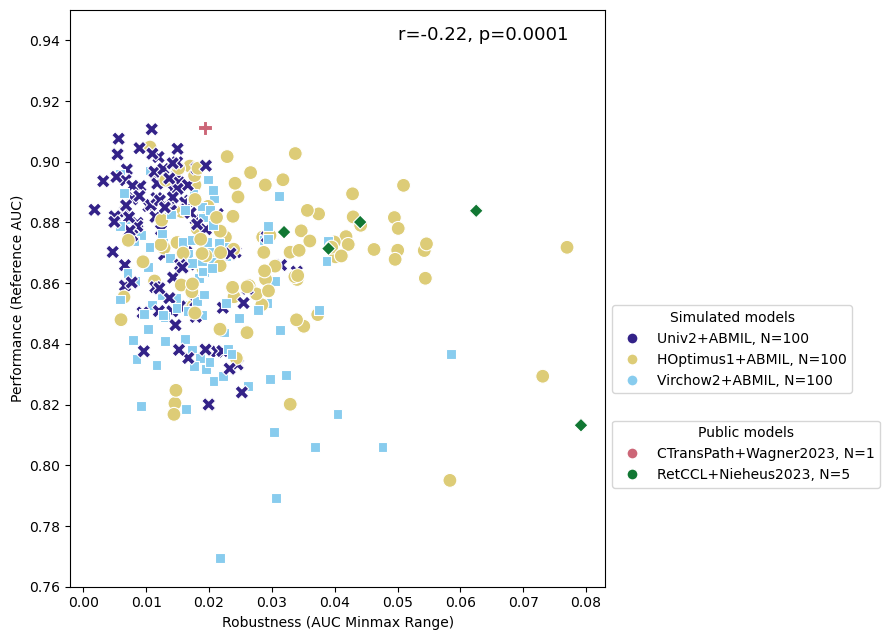

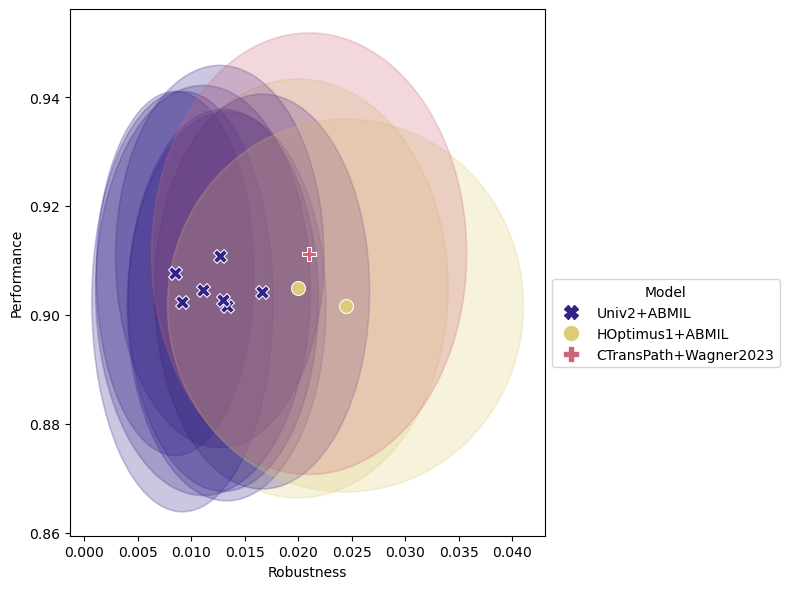

Model: Univ2+ABMIL, Median Range CI width: 0.0186, Median AUC CI width: 0.0714
Model: HOptimus1+ABMIL, Median Range CI width: 0.0307, Median AUC CI width: 0.0727
Model: CTransPath+Wagner2023, Median Range CI width: 0.0295, Median AUC CI width: 0.0811


/tmp/ipykernel_2721325/2494719956.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zoom_df["range_CI"] = zoom_df["range_upper_ci"] - zoom_df["range_lower_ci"]
/tmp/ipykernel_2721325/2494719956.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zoom_df["auc_CI"] = zoom_df["test_upper_ci"] - zoom_df["test_lower_ci"]


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

sim_models = ["Univ2+ABMIL", "HOptimus1+ABMIL", "Virchow2+ABMIL"]
## Non-bootstrap range and reference AUC
df_all["range"] = df_all.groupby("exp_idx")["test_auc"].transform(lambda x: x.max() - x.min())
merged = df_all[df_all["setting"] == "Reference"].merge(range_df, on="exp_idx", how="left")
merged = merged.rename(columns={"test_auc": "auc_ref"})
merged = merged.rename(columns={"test_mean_auc": "auc_mean_ref"})

print(f"Pearson r, p-value (non-bootstrapped) between robustness and performance: {pearsonr(merged['range'], merged['auc_ref'])}")
plt.figure(figsize=(9, 6.5))
sns.scatterplot(
    data=merged,
    x="range",
    y="auc_ref",
    hue="foundation_model",
    style="foundation_model",
    s=100,
    palette=model_palette
)
# add correlation info in plot
corr_coef, p_value = pearsonr(merged['range'], merged['auc_ref'])
plt.text(0.05, 0.94, f'r={corr_coef:.2f}, p={p_value:.4f}', fontsize=13)
plt.ylim(top=0.95)
plt.yticks(np.arange(0.76, 0.95, 0.02))
plt.xlabel("Robustness (AUC Minmax Range)")
plt.ylabel("Performance (Reference AUC)")
# Simulated models legend
sim_handles = [Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=model_palette[m], markersize=8,
                       label=f"{m}, N=100") for m in sim_models]

# Public models legend
public_models = [m for m in list(merged["foundation_model"].unique()) if m not in sim_models] 
public_handles = [Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=model_palette[m], markersize=8,
                          label=f"{m}, N={len(merged[merged['foundation_model']==m])}") for m in public_models]

# Add legends
leg1 = plt.legend(handles=sim_handles, title="Simulated models", bbox_to_anchor=(1, 0.5))
leg2 = plt.legend(handles=public_handles, title="Public models", bbox_to_anchor=(1, 0.3))
plt.gca().add_artist(leg1)
plt.tight_layout()
plt.show()

## Zoom in on top candidates, consider bootstrapped range and reference AUC + CI
zoom_df = merged[(merged["range"] < 0.03) & (merged["auc_ref"] > 0.90)]
plt.figure(figsize=(8, 6))
ax = plt.gca()
# --- CI ellipses (background) ---
for _, row in zoom_df.iterrows():
    color = model_palette[row["foundation_model"]]

    ellipse = Ellipse(
        (row["range_mean"], row["auc_ref"]),
        width=row["range_upper_ci"] - row["range_lower_ci"],
        height=row["test_upper_ci"] - row["test_lower_ci"],
        facecolor=color,
        edgecolor=color,
        alpha=0.25,
        linewidth=1.2,
        zorder=1
    )
    ax.add_patch(ellipse)

# --- main scatter (foreground) ---
marker_dict = {
    "Univ2+ABMIL": "X",
    "HOptimus1+ABMIL": "o",
    "CTransPath+Wagner2023": "P"
}
for model in zoom_df["foundation_model"].unique():
    sub_df = zoom_df[zoom_df["foundation_model"] == model]
    plt.scatter(
        sub_df["range_mean"],
        sub_df["auc_ref"],
        s=100,
        color=model_palette[model],
        marker=marker_dict[model],
        label=model,
        edgecolor="white",
        linewidth=0.75,
        zorder=4 
    )


plt.xlabel("Robustness")
plt.ylabel("Performance")
handles = []
for model, marker in marker_dict.items():
    handles.append(
        Line2D(
            [0], [0],
            marker=marker,
            color=model_palette[model],
            label=model,
            linestyle="",
            markersize=10
        )
    )

plt.legend(handles=handles, title="Model", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

zoom_df["range_CI"] = zoom_df["range_upper_ci"] - zoom_df["range_lower_ci"]
zoom_df["auc_CI"] = zoom_df["test_upper_ci"] - zoom_df["test_lower_ci"]

# per foundation model zoomed median robustness CI width
for model in zoom_df["foundation_model"].unique():
    sub_df = zoom_df[zoom_df["foundation_model"] == model]
    median_range_ci = sub_df["range_upper_ci"] - sub_df["range_lower_ci"]
    median_auc_ci = sub_df["test_upper_ci"] - sub_df["test_lower_ci"]
    print(f"Model: {model}, Median Range CI width: {median_range_ci.median():.4f}, Median AUC CI width: {median_auc_ci.median():.4f}")

#### Setting and Model comparison

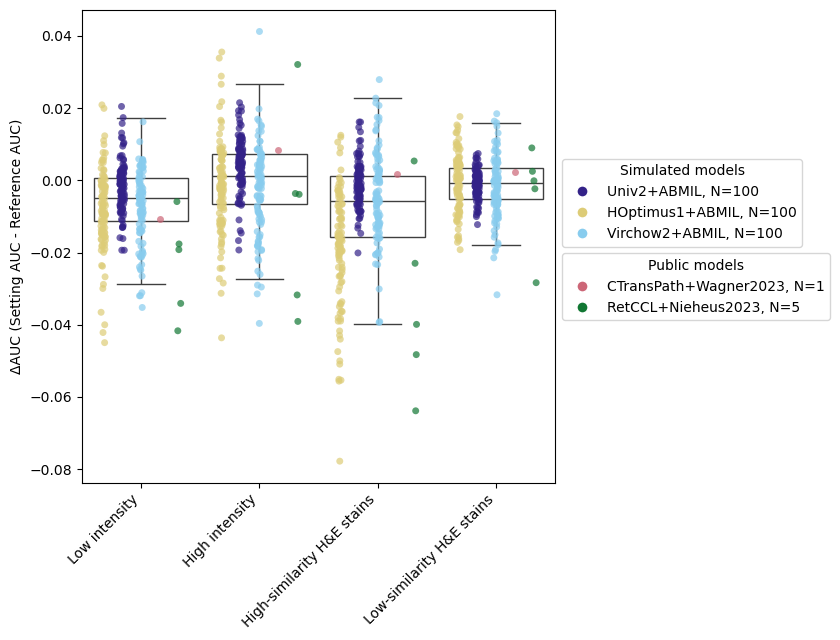

,Median,Q1,Q3,IQR
setting,,,,
High intensity,0.001154,-0.006523,0.007334,0.013857
High-similarity H&E stains,-0.005708,-0.015753,0.001142,0.016896
Low intensity,-0.004972,-0.011303,0.000496,0.011799
Low-similarity H&E stains,-0.000713,-0.005162,0.003433,0.008595


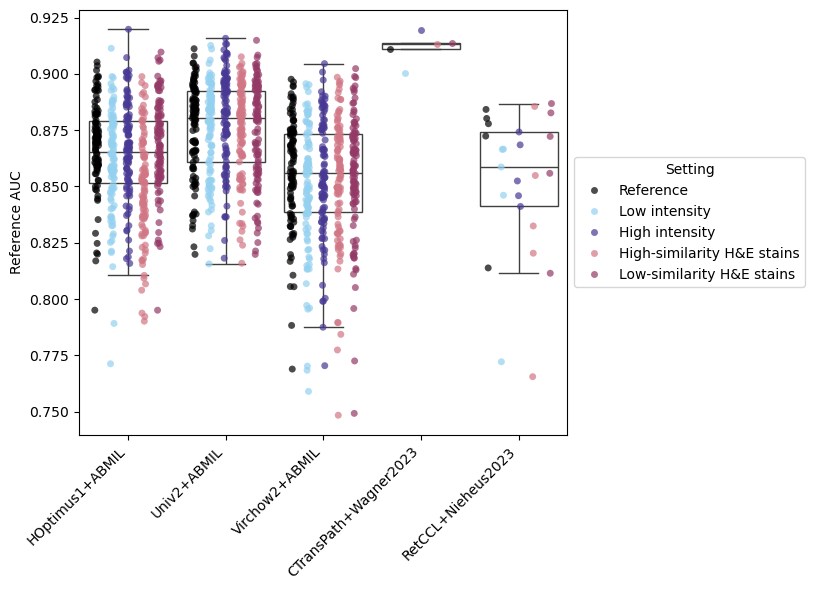

,Median,Q1,Q3,IQR
foundation_model,,,,
CTransPath+Wagner2023,0.913266,0.909882,0.915033,0.005152
HOptimus1+ABMIL,0.863212,0.848432,0.878217,0.029784
RetCCL+Nieheus2023,0.855348,0.838946,0.869401,0.030455
Univ2+ABMIL,0.880223,0.860321,0.892624,0.032303
Virchow2+ABMIL,0.855141,0.838430,0.872541,0.034111


Overall AUC range across all models: 0.1419, min=0.7693, max=0.9112
Overall robustness (AUC range) across all models: 0.0790, min=0.0071, max=0.0861
Model: HOptimus1+ABMIL, Pearson r=-0.140, p-value=0.16263
Model: Univ2+ABMIL, Pearson r=-0.509, p-value=0.00000
Model: Virchow2+ABMIL, Pearson r=-0.364, p-value=0.00022
Model: RetCCL+Nieheus2023, Pearson r=-0.739, p-value=0.15368


In [21]:
# ----------------------------------------------------------------------
# Setting Comparison - Reference AUC
# ----------------------------------------------------------------------
plt.figure(figsize=(8.5, 6.5))
ref_means = df_all[df_all["setting"] == "Reference"].groupby("exp_idx")["test_mean_auc"].mean()

# Normalize test_mean_auc to reference
df_plot = df_all[df_all["setting"] != "Reference"].copy()
df_plot["norm_auc"] = df_plot.apply(lambda r: r["test_mean_auc"] - ref_means[r["exp_idx"]], axis=1)

# Boxplot: aggregates all foundation models per setting
sns.boxplot(
    data=df_plot,
    x="setting",
    y="norm_auc",
    showcaps=True,
    boxprops={"facecolor": "none"},
    whiskerprops={"linewidth": 1},
    showfliers=False
)

sns.stripplot(
    data=df_plot,
    x="setting",
    y="norm_auc",
    hue="foundation_model",
    palette=model_palette,
    dodge=True,
    jitter=True,
    alpha=0.7
)

plt.xticks(rotation=45, ha="right")

# Simulated models legend
sim_handles = [Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=model_palette[m], markersize=8,
                       label=f"{m}, N=100") for m in sim_models]

# Public models legend
public_models = [m for m in list(merged["foundation_model"].unique()) if m not in sim_models] 
public_handles = [Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=model_palette[m], markersize=8,
                          label=f"{m}, N={len(merged[merged['foundation_model']==m])}") for m in public_models]

# Add legends
leg1 = plt.legend(handles=sim_handles, title="Simulated models", bbox_to_anchor=(1, 0.7))
leg2 = plt.legend(handles=public_handles, title="Public models", bbox_to_anchor=(1, 0.5))
plt.gca().add_artist(leg1)
plt.ylabel("ΔAUC (Setting AUC - Reference AUC)")
plt.xlabel("")
plt.tight_layout()
plt.show()

summary = df_plot.groupby("setting")["norm_auc"].agg([
    ("Median", "median"),
    ("Q1", lambda x: x.quantile(0.25)),
    ("Q3", lambda x: x.quantile(0.75))
])
summary["IQR"] = summary["Q3"] - summary["Q1"]
display(summary)
# ----------------------------------------------------------------------
# 2) Foundatino model Comparison 
# ----------------------------------------------------------------------
plt.figure(figsize=(8.25, 6))

sns.boxplot(
    data=df_all,
    x="foundation_model",
    y="test_mean_auc",
    showcaps=True,
    boxprops={"facecolor": "none"},
    whiskerprops={"linewidth": 1},
    showfliers=False
)

# Strip plot: colored by setting
sns.stripplot(
    data=df_all,
    x="foundation_model",
    y="test_mean_auc",
    hue="setting",
    palette=setting_palette,
    dodge=True,
    jitter=True,
    alpha=0.7
)

plt.xticks(rotation=45, ha="right")

# Legend to the right of the plot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[:len(df_all.foundation_model.unique())],
    labels[:len(df_all.foundation_model.unique())],
    title="Setting",
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)
plt.ylabel("Reference AUC")
plt.xlabel("")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 4b) Statistical properties of foundation models
# ----------------------------------------------------------------------
summary = df_plot.groupby("foundation_model")["test_mean_auc"].agg([
    ("Median", "median"),
    ("Q1", lambda x: x.quantile(0.25)),
    ("Q3", lambda x: x.quantile(0.75))
])
summary["IQR"] = summary["Q3"] - summary["Q1"]
display(summary)

## Min max reference AUC and range across all models
print(f"Overall AUC range across all models: {merged['auc_ref'].max() - merged['auc_ref'].min():.4f}, min={merged['auc_ref'].min():.4f}, max={merged['auc_ref'].max():.4f}")
print(f"Overall robustness (AUC range) across all models: {merged['range_mean'].max() - merged['range_mean'].min():.4f}, min={merged['range_mean'].min():.4f}, max={merged['range_mean'].max():.4f}")

#------------------------------------------------------
# Pearson correlation between robustness and performance per foundation model
for model in merged["foundation_model"].unique():
    sub_df = merged[merged["foundation_model"] == model]
    if len(sub_df) < 2:
        continue
    corr_coef, p_value = pearsonr(sub_df['range_mean'], sub_df['auc_ref'])
    print(f"Model: {model}, Pearson r={corr_coef:.3f}, p-value={p_value:.5f}")